# The debt extension — reconciling the register to the official totals

This notebook explains the twelve `debt_*.csv` files in
[`../deliverables/`](../deliverables): the reconciliation of central-government
debt securities interest and financing to the package's own general-government
aggregates (`GF01_7`, `NLB`), for the United Kingdom, France and Germany.

**Read this before the charts below.** The per-security register described in
`DEBT_KICKOFF.md` — every gilt, OAT and Bund, its coupon, its position through
time — is built for **Germany** (the Finanzagentur's own per-ISIN lists,
D-S10-004) and the **United Kingdom** (the DMO's reports, D-S10-005), and is
shown in §7. **France** (the AFT's encours
pages and auction histories, D-S10-006/007), and is shown in §7; the
**aggregate class-level layer** (DD8) — the ministries' and statistical
offices' own published totals *by instrument class* (`debt_class_aggregates`)
— remains the register step for the years before each register starts and
the V31/V39 cross-check everywhere. The two reconciliation chains — interest to
`GF01_7`, financing to `NLB` — are built on top of whichever register a
country-year has, exactly as `DEBT_KICKOFF.md` §8 specifies: register sum →
step A (finance-ministry book) → step B (S.1311 national accounts) → step C
(S.13 package total), with every bridge item either computed from the
register, official or declared, and

    official_total = carried_from_previous_step + Σ bridge items + residual

held per (country, year, step). **Every residual here is published, never
allocated** — no line in this notebook is scaled, tilted or adjusted to make
a total match; where the chain does not close, the gap is drawn as its own
bar or its own line.

Everything below is read from `../deliverables/` and nothing is recomputed
from `../data/`.


In [1]:
import io
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "debt_reference_series.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv", float_precision="round_trip")

REF = load("debt_reference_series")
OFFICIAL = load("debt_official_totals")
CLASS_AGG = load("debt_class_aggregates")
INTEREST = load("debt_interest_reconciliation")
FINANCING = load("debt_financing_reconciliation")

REF["date"] = pd.to_datetime(REF["date"])
COUNTRY = {"GBR": "United Kingdom", "FRA": "France", "DEU": "Germany"}

# Fixed categorical palette, assigned by role and reused across every chart in
# this notebook: the same colour always means the same instrument class or
# the same chain step, whichever country or section it appears in.
BLUE, ORANGE, GREEN, PURPLE, RED, TEAL, BROWN, GOLD = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8456ce",
    "#d64550", "#2ba8a0", "#a8763e", "#d1a62b",
)
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

CLASS_COLOR = {
    "fixed_bullet": BLUE, "floating": PURPLE, "inflation_linked": GREEN,
    "bill": ORANGE, "other": BROWN, "mixed": TEAL,
}
STEP_LABEL = {
    "A_cg_cash": "A · CG cash interest", "B_s1311_d41": "B · S.1311 D.41",
    "C_s13_gf01_7": "C · GF01_7",
    "A_cg_cash_requirement": "A · CG net cash requirement",
    "B_s1311_b9": "B · S.1311 B.9", "C_s13_nlb": "C · NLB",
}
STEP_COLOR = {"A": BLUE, "B": ORANGE, "C": GREEN}


def step_color(step):
    return STEP_COLOR[step[0]]


plt.rcParams.update({
    "figure.figsize": (7, 3), "figure.dpi": 72,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 1.8,
})


def _palette():
    '''A fixed palette of exactly the colours these charts use.

    Quantising a PNG at full colour depth is what keeps this notebook under
    1 MB and renderable everywhere; an *adaptive* palette would instead
    allocate slots by pixel count and crush thin lines to a nearby background
    tint. Fixing the palette -- each mark colour plus its blends toward the
    two backgrounds -- means every hue survives regardless of how little of
    the canvas it covers.
    '''
    from matplotlib.colors import to_rgb

    entries = [to_rgb(SURFACE), to_rgb(SHADE)]
    marks = (INK, MUTED, AXIS, BLUE, ORANGE, GREEN, PURPLE, RED, TEAL, BROWN, GOLD)
    for mark in marks:
        m = to_rgb(mark)
        for ground in (SURFACE, SHADE):
            g = to_rgb(ground)
            entries += [tuple(m[i] + (g[i] - m[i]) * t for i in range(3))
                        for t in (0.0, 0.2, 0.4, 0.6, 0.8)]
    flat = [round(255 * v) for e in entries for v in e]
    pal = Image.new("P", (1, 1))
    pal.putpalette(flat + [0] * (768 - len(flat)))
    return pal


PALETTE = _palette()


def show(fig):
    '''Display a figure as a PNG quantised onto the fixed palette above.'''
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=plt.rcParams["figure.dpi"], bbox_inches="tight")
    plt.close(fig)
    small = Image.open(buf).convert("RGB").quantize(
        palette=PALETTE, dither=Image.Dither.NONE)
    out = io.BytesIO()
    small.save(out, format="PNG", optimize=True)
    display(Image_display(data=out.getvalue()))


def thousands(ax, axis="y"):
    getattr(ax, f"{axis}axis").set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


/tmp/ipykernel_807/1278449642.py:12: DtypeWarning: Columns (0: base_period) have mixed types. Specify dtype option on import or set low_memory=False.
  load = lambda n: pd.read_csv(DELIV / f"{n}.csv", float_precision="round_trip")


## 1. Reference series

`debt_reference_series.csv` holds the price indices and interest rates that
inflation-linked and floating-rate securities pay on (DEBT_KICKOFF.md §4.2):
350 series in total, of which **332 are the Bank of England's nominal, real,
inflation and OIS month-end yield curves** — one series per maturity point.
Those are summarised in one chart (the UK nominal curve at three tenors) and
otherwise left out of the table below, which lists the other 18 series in
full: their span is what matters here, not their shape.


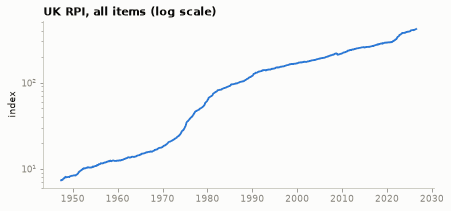

In [2]:
def line(ax, series_id, label=None, color=BLUE, **kw):
    d = REF[REF.series_id == series_id].sort_values("date")
    ax.plot(d.date, d.value, color=color, label=label or series_id, **kw)
    return d


fig, ax = plt.subplots()
line(ax, "UK_RPI", color=BLUE)
ax.set_yscale("log")
ax.set_title("UK RPI, all items (log scale)")
ax.set_ylabel("index")
show(fig)


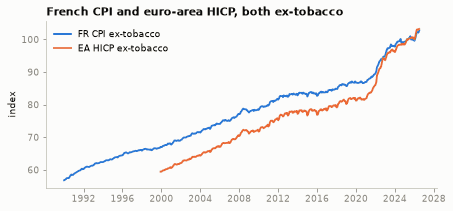

In [3]:
fig, ax = plt.subplots()
line(ax, "FR_CPI_XT", "FR CPI ex-tobacco", BLUE)
line(ax, "EA_HICP_XT", "EA HICP ex-tobacco", ORANGE)
ax.set_title("French CPI and euro-area HICP, both ex-tobacco")
ax.set_ylabel("index")
ax.legend()
show(fig)


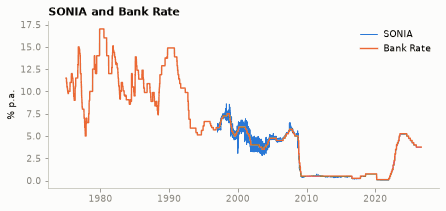

In [4]:
fig, ax = plt.subplots()
line(ax, "UK_SONIA", "SONIA", BLUE, linewidth=0.9)
line(ax, "UK_BANK_RATE", "Bank Rate", ORANGE, linewidth=1.4)
ax.set_title("SONIA and Bank Rate")
ax.set_ylabel("% p.a.")
ax.legend()
show(fig)


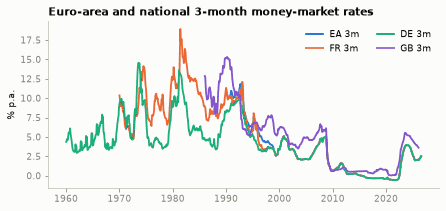

In [5]:
fig, ax = plt.subplots()
line(ax, "EA_MM_3M", "EA 3m", BLUE)
line(ax, "FR_IR3", "FR 3m", ORANGE)
line(ax, "DE_IR3", "DE 3m", GREEN)
line(ax, "GB_IR3", "GB 3m", PURPLE)
ax.set_title("Euro-area and national 3-month money-market rates")
ax.set_ylabel("% p.a.")
ax.legend(ncol=2)
show(fig)


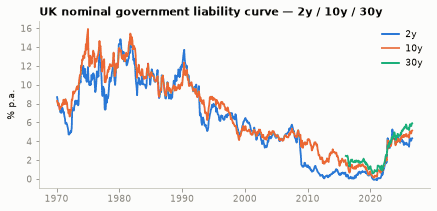

In [6]:
fig, ax = plt.subplots()
line(ax, "UK_GLC_NOMINAL_2Y", "2y", BLUE)
line(ax, "UK_GLC_NOMINAL_10Y", "10y", ORANGE)
line(ax, "UK_GLC_NOMINAL_30Y", "30y", GREEN)
ax.set_title("UK nominal government liability curve — 2y / 10y / 30y")
ax.set_ylabel("% p.a.")
ax.legend()
show(fig)


In [7]:
CURVE_PREFIX = ("UK_GLC_", "UK_OIS_")
non_curve = REF[~REF.series_id.str.startswith(CURVE_PREFIX)]
span = (non_curve.groupby("series_id")
        .agg(first_date=("date", "min"), last_date=("date", "max"),
             n_obs=("date", "size"), unit=("unit", "first"))
        .sort_index())
print(f"{REF.series_id.nunique()} series in total; {span.shape[0]} shown here, "
      f"{REF.series_id.nunique() - span.shape[0]} are BoE curve points (UK_GLC_*/UK_OIS_*).")
span


355 series in total; 23 shown here, 332 are BoE curve points (UK_GLC_*/UK_OIS_*).


,first_date,last_date,n_obs,unit
series_id,,,,
DE_BUND_YIELD_10Y,1997-08-07,2026-09-09,7384,pct_pa
DE_HICP_XT,1996-01-01,2026-07-01,367,index
DE_IR3,1960-01-01,2026-08-01,800,pct_pa
DE_LT10,1956-05-01,2026-08-01,844,pct_pa
DE_MCBY,1980-01-01,2026-07-01,559,pct_pa
EA_EONIA,1994-01-01,2021-12-01,336,pct_pa
EA_ESTR,2019-10-01,2026-09-08,1777,pct_pa
EA_EURIBOR_3M,1994-01-01,2026-08-01,392,pct_pa
EA_EURIBOR_6M,1994-01-01,2026-08-01,392,pct_pa


## 2. Official intermediates

`debt_official_totals.csv` holds the six numbers each country-year can carry:
the three interest-chain totals (step A finance-ministry cash interest, step
B S.1311 D.41, step C the package's `GF01_7`) and the three financing-chain
totals (step A the central-government net cash requirement — CGNCR / besoin
de financement / Nettokreditaufnahme — step B S.1311 `B.9`, step C the
package's `NLB`). A cell is null where the source is unreachable (OQ-8, e.g.
the AFT for France) or the year is outside the source's coverage.

**Sign note for financing.** The net cash requirement is published as a
borrowing *need* (positive when the government borrows); `B.9` and `NLB` are
net lending(+)/borrowing(–), the opposite sign. The chart below therefore
plots **NET BORROWING = −B.9** and **−NLB** alongside CGNCR/NKA exactly as
published, so the three lines sit on the same side of zero and can be read
together.


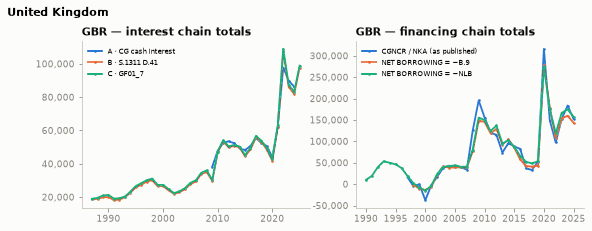

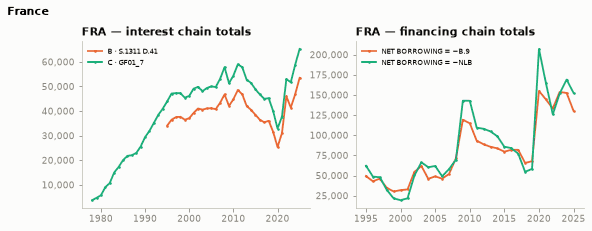

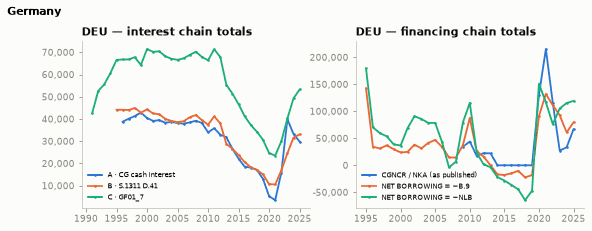

In [8]:
def official_pivot(iso3, chain):
    sub = OFFICIAL[(OFFICIAL.iso3 == iso3) & (OFFICIAL.chain == chain)]
    return sub.pivot_table(index="year", columns="step", values="value_lcu_mn")


for iso in ["GBR", "FRA", "DEU"]:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))

    p = official_pivot(iso, "interest")
    for step in ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"]:
        if step in p.columns:
            axes[0].plot(p.index, p[step], color=step_color(step),
                         marker=".", markersize=3, label=STEP_LABEL[step])
    axes[0].set_title(f"{iso} — interest chain totals")
    thousands(axes[0])
    axes[0].legend(fontsize=7)

    p = official_pivot(iso, "financing")
    if "A_cg_cash_requirement" in p.columns:
        axes[1].plot(p.index, p["A_cg_cash_requirement"], color=STEP_COLOR["A"],
                     marker=".", markersize=3, label="CGNCR / NKA (as published)")
    if "B_s1311_b9" in p.columns:
        axes[1].plot(p.index, -p["B_s1311_b9"], color=STEP_COLOR["B"],
                     marker=".", markersize=3, label="NET BORROWING = −B.9")
    if "C_s13_nlb" in p.columns:
        axes[1].plot(p.index, -p["C_s13_nlb"], color=STEP_COLOR["C"],
                     marker=".", markersize=3, label="NET BORROWING = −NLB")
    axes[1].set_title(f"{iso} — financing chain totals")
    thousands(axes[1])
    axes[1].legend(fontsize=7)

    fig.suptitle(COUNTRY[iso], x=0.01, ha="left", fontsize=10.5, fontweight="bold", y=1.04)
    show(fig)


## 3. Aggregate layer

`debt_class_aggregates.csv` is the DD8 stand-in for the register: the
ministries' and statistical offices' own instrument-class totals. It carries
several *alternative* measures of the same stock side by side (a source's own
grand total next to the components it sums to) — stacking all of them would
double-count, so each chart below uses exactly the rows the reconciliation
chains themselves use (`in_register == True`), and never sums a total row
together with its components:

- **Germany** — every in-register row: the eleven Bundeswertpapiere lines
  (Bunds by maturity band, Bobls, Schätze, Bubills, Bund/Bobl-ei, green
  twins, other and the WSF top-up issuance), no separate "total" row exists
  at this level.
- **United Kingdom** — `gilts_all` (the DMR's own gilts total, `mixed` class
  because the DMR does not split it by class at every date) plus
  `treasury_bills`; a second chart shows the DMR's own conventional /
  index-linked / bills split, available only 2023–2025.
- **France** — `btf`, `oat_btan_fixed` and `oati_oatei` from 2009, the AFT's
  own class split; `dette_négociable_total`, `oat_btan_all` and `taux_fixe`
  are alternative totals and are excluded here.


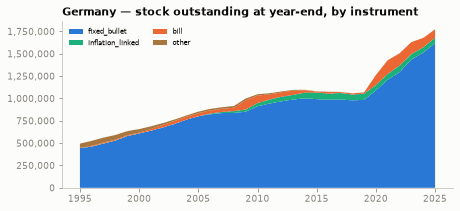

In [9]:
def stock_stack(sub, title, ax=None):
    # Stacks stock_year_end by instrument_class, summing sub-types within a
    # class (Germany's eleven Bundeswertpapiere lines collapse to four).
    p = sub.pivot_table(index="year", columns="instrument_class", values="value_lcu_mn", aggfunc="sum")
    order = sorted(p.columns, key=lambda c: list(CLASS_COLOR).index(c) if c in CLASS_COLOR else 99)
    colors = [CLASS_COLOR.get(c, MUTED) for c in order]
    ax = ax or plt.subplots()[1]
    ax.stackplot(p.index, [p[c].fillna(0) for c in order], labels=order, colors=colors)
    ax.set_title(title)
    thousands(ax)
    ax.legend(fontsize=7, ncol=2)
    return ax


deu_stock = CLASS_AGG[(CLASS_AGG.iso3 == "DEU") & (CLASS_AGG.in_register) &
                       (CLASS_AGG.measure == "stock_year_end")]
fig, ax = plt.subplots()
stock_stack(deu_stock, "Germany — stock outstanding at year-end, by instrument", ax)
show(fig)


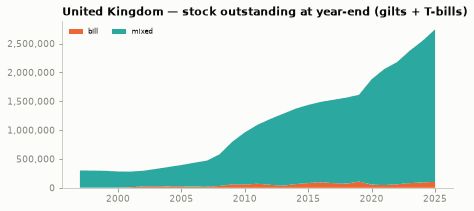

In [10]:
gbr_stock = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "stock_year_end") &
                       (CLASS_AGG.sub_type.isin(["gilts_all", "treasury_bills"]))]
fig, ax = plt.subplots()
stock_stack(gbr_stock, "United Kingdom — stock outstanding at year-end (gilts + T-bills)", ax)
show(fig)


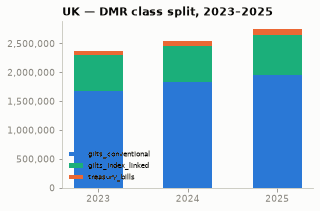

In [11]:
gbr_dmr = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "stock_year_end") &
                     (CLASS_AGG.year >= 2023) &
                     (CLASS_AGG.sub_type.isin(
                         ["gilts_conventional", "gilts_index_linked", "treasury_bills"]))]
p = gbr_dmr.pivot_table(index="year", columns="sub_type", values="value_lcu_mn")
fig, ax = plt.subplots(figsize=(4.5, 3))
x = range(len(p.index))
bottom = pd.Series(0.0, index=p.index)
for col in ["gilts_conventional", "gilts_index_linked", "treasury_bills"]:
    cls = gbr_dmr[gbr_dmr.sub_type == col].instrument_class.iloc[0]
    ax.bar(x, p[col], bottom=bottom, color=CLASS_COLOR[cls], label=col, width=0.55)
    bottom += p[col].fillna(0)
ax.set_xticks(list(x)); ax.set_xticklabels(p.index.astype(str))
ax.set_title("UK — DMR class split, 2023–2025")
thousands(ax)
ax.legend(fontsize=7)
show(fig)


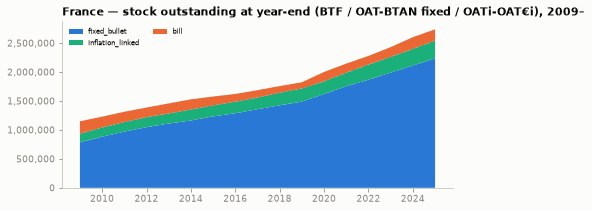

In [12]:
fra_stock = CLASS_AGG[(CLASS_AGG.iso3 == "FRA") & (CLASS_AGG.measure == "stock_year_end") &
                       (CLASS_AGG.sub_type.isin(["btf", "oat_btan_fixed", "oati_oatei"]))]
fig, ax = plt.subplots()
stock_stack(fra_stock, "France — stock outstanding at year-end (BTF / OAT-BTAN fixed / OATi-OAT€i), 2009–", ax)
show(fig)


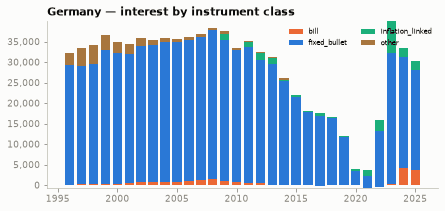

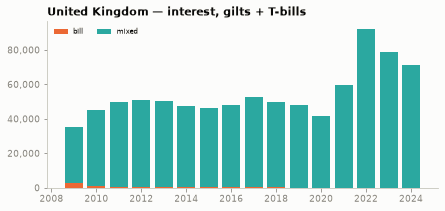

In [13]:
def class_bars(sub, title, ax=None):
    p = sub.pivot_table(index="year", columns="instrument_class", values="value_lcu_mn", aggfunc="sum")
    ax = ax or plt.subplots()[1]
    bottom = pd.Series(0.0, index=p.index)
    for c in p.columns:
        ax.bar(p.index, p[c].fillna(0), bottom=bottom, color=CLASS_COLOR.get(c, MUTED),
               label=c, width=0.8)
        bottom += p[c].fillna(0)
    ax.set_title(title)
    thousands(ax)
    ax.legend(fontsize=7, ncol=2)
    return ax


deu_int = CLASS_AGG[(CLASS_AGG.iso3 == "DEU") & (CLASS_AGG.in_register) & (CLASS_AGG.measure == "interest")]
fig, ax = plt.subplots()
class_bars(deu_int, "Germany — interest by instrument class", ax)
show(fig)

gbr_int = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "interest") &
                     (CLASS_AGG.sub_type.isin(["gilts_all", "treasury_bills"]))]
fig, ax = plt.subplots()
class_bars(gbr_int, "United Kingdom — interest, gilts + T-bills", ax)
show(fig)


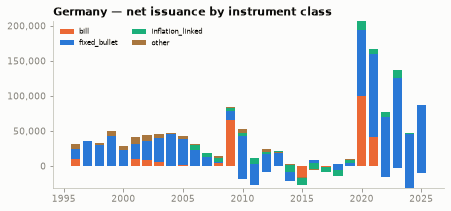

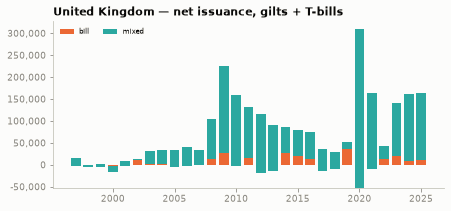

In [14]:
deu_ni = CLASS_AGG[(CLASS_AGG.iso3 == "DEU") & (CLASS_AGG.in_register) & (CLASS_AGG.measure == "net_issuance")]
fig, ax = plt.subplots()
class_bars(deu_ni, "Germany — net issuance by instrument class", ax)
show(fig)

gbr_ni = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "net_issuance") &
                    (CLASS_AGG.sub_type.isin(["gilts_all", "treasury_bills"]))]
fig, ax = plt.subplots()
class_bars(gbr_ni, "United Kingdom — net issuance, gilts + T-bills", ax)
show(fig)


France publishes net issuance at class level for BTF only among these three sub-types (['btf']); OAT-BTAN fixed and OATi/OAT€i carry a stock series but no separate net-issuance line here.


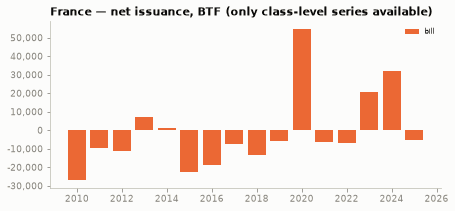

In [15]:
fra_ni = CLASS_AGG[(CLASS_AGG.iso3 == "FRA") & (CLASS_AGG.measure == "net_issuance") &
                    (CLASS_AGG.sub_type.isin(["btf", "oat_btan_fixed", "oati_oatei"]))]
print("France publishes net issuance at class level for BTF only among these three "
      f"sub-types ({fra_ni.sub_type.unique().tolist()}); OAT-BTAN fixed and OATi/OAT€i "
      "carry a stock series but no separate net-issuance line here.")
fig, ax = plt.subplots()
class_bars(fra_ni, "France — net issuance, BTF (only class-level series available)", ax)
show(fig)


## 4. The interest chain

`debt_interest_reconciliation.csv` holds, per (country, year, step), the
carried-forward value, every bridge item, the official total and the
residual — `official_total = carried + Σ bridge items + residual`
(DEBT_KICKOFF.md §8, V32). The waterfalls below take **the latest year each
country's step-C residual is not null** and show all three steps side by
side: the grey bar is the value carried in from the previous step, coloured
bars are bridge items (orange where negative), the red bar is the residual,
and the dark bar on the right is the official total the step reconciles to.
Where a step has no data for that year at all (register or step A can be
blocked independently of C), the panel says so instead of drawing empty
bars. Bridge items beyond the six largest by size are grouped into "other".


In [16]:
def step_items(df, iso3, step, year, max_bridge=6):
    sub = df[(df.iso3 == iso3) & (df.step == step) & (df.year == year)]
    d = dict(zip(sub.item, sub.value_lcu_mn))
    carried = d.get("carried_from_previous_step")
    official = d.get("official_total")
    residual = d.get("residual")
    bridge = [(k, v) for k, v in d.items()
              if k not in ("carried_from_previous_step", "official_total", "residual")
              and pd.notna(v) and v != 0]
    bridge.sort(key=lambda kv: -abs(kv[1]))
    if len(bridge) > max_bridge:
        head, tail = bridge[:max_bridge - 1], bridge[max_bridge - 1:]
        bridge = head + [(f"other ({len(tail)})", sum(v for _, v in tail))]
    return carried, bridge, residual, official


def waterfall(ax, iso3, df, step, year, title):
    carried, bridge, residual, official = step_items(df, iso3, step, year)
    if pd.isna(carried) and pd.isna(official):
        ax.text(0.5, 0.5, "no data\nfor this year", ha="center", va="center",
                transform=ax.transAxes, color=MUTED, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title)
        return
    labels, lefts, widths, colors = [], [], [], []
    cum = 0.0
    if pd.notna(carried):
        labels.append("carried"); lefts.append(0); widths.append(carried); colors.append(MUTED)
        cum = carried
    for lab, val in bridge:
        lefts.append(min(cum, cum + val)); widths.append(abs(val))
        colors.append(BLUE if val >= 0 else ORANGE)
        labels.append(lab.replace("out_of_register_", "").replace("_", " ")[:22])
        cum += val
    if pd.notna(residual):
        lefts.append(min(cum, cum + residual)); widths.append(abs(residual))
        colors.append(RED); labels.append("residual")
        cum += residual
    y = range(len(labels))
    ax.barh(list(y), widths, left=lefts, color=colors, height=0.65)
    if pd.notna(official):
        labels.append("official total")
        y = range(len(labels))
        ax.barh([len(labels) - 1], [official], left=[0], color=INK, height=0.65)
    ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=6.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9.5)
    thousands(ax, axis="x")
    ax.tick_params(axis="x", labelsize=6.5, rotation=30)


def waterfall_page(df, iso3, steps, chain_name):
    c_step = steps[-1]
    year = df[(df.iso3 == iso3) & (df.step == c_step) &
              (df.item == "residual")].dropna(subset=["value_lcu_mn"]).year.max()
    fig, axes = plt.subplots(1, len(steps), figsize=(3.4 * len(steps), 3.2))
    for ax, step in zip(axes, steps):
        waterfall(ax, iso3, df, step, year, f"{STEP_LABEL[step]}, {year}")
    fig.suptitle(f"{COUNTRY[iso3]} — {chain_name} chain, {year}", x=0.01, ha="left",
                 fontsize=10.5, fontweight="bold", y=1.05)
    show(fig)
    return year


def residual_over_time(df, iso3, steps, title):
    fig, ax = plt.subplots()
    for step in steps:
        sub = df[(df.iso3 == iso3) & (df.step == step) & (df.item == "residual")]
        s = sub.set_index("year").value_lcu_mn.sort_index()
        full = s.reindex(range(int(s.index.min()), int(s.index.max()) + 1))
        ax.plot(full.index, full.values, color=STEP_COLOR[step[0]],
                marker=".", markersize=3, label=STEP_LABEL[step])
    ax.axhline(0, color=AXIS, linewidth=0.7)
    ax.set_title(title)
    thousands(ax)
    ax.legend(fontsize=7)
    show(fig)


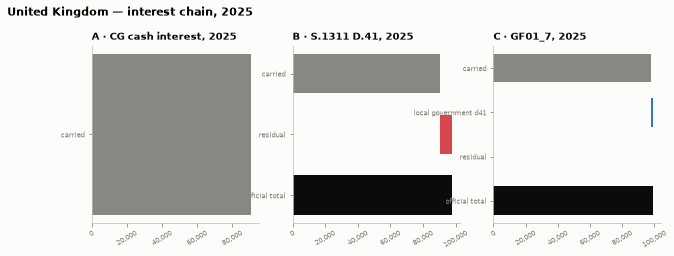

In [17]:
gbr_year = waterfall_page(INTEREST, "GBR", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"], "interest")


**Reading the UK panels.** The register step is the computed per-security
register (§7) on the **accrued** basis: HMT's NLF accounts are accruals-based,
so the step-A total already carries the accrued RPI uplift on index-linked
gilts and the amortisation of issue discounts, and the register enters on the
same footing (no value-date bridges as for Germany). The only out-of-register
items are National Savings and the other NLF finance costs; the residual is
within ±£3.3bn in every year 2010–2024 except 2009 (deflation: the register's
uplift accrual is negative), 2012 and 2021. Step A and the register sum are
null for 2025 — a *publication lag* of the NLF series, not a blocked source.
Step B carries no bridge items: HMT's interest feeds `S.1311 D.41` directly.
Step C's residual (£1.1bn against a £98.9bn total) is the **COFOG-vs-D.41
wedge plus intra-`S.13` consolidation**.


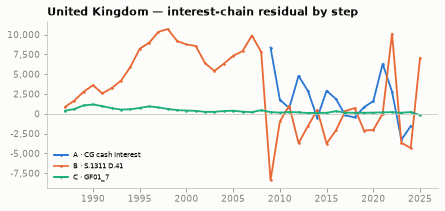

In [18]:
residual_over_time(INTEREST, "GBR", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"],
                    "United Kingdom — interest-chain residual by step")


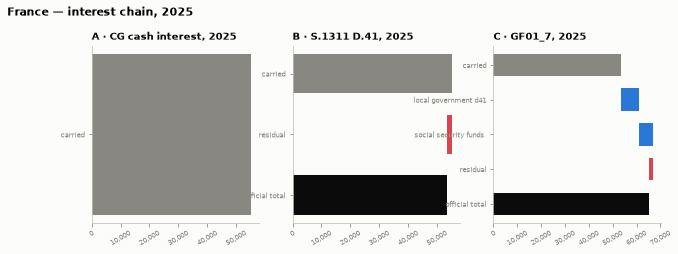

In [19]:
fra_year = waterfall_page(INTEREST, "FRA", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"], "interest")


**Reading the France panels.** Step A is entirely blocked: `FRA_PLF_P117`
(the PLF programme 117 swaps/loans detail that step A's bridge would use) has
no data in this run (OQ-8), so both the register sum and step A's official
total are null in every year, not just 2025 — there is no "carried" bar to
draw. Step B shows the official total alone: the PLF's central-government
cash interest feeds `D.41` with no declared bridge items. Step C's residual
(−€1.6bn) is **subsector consolidation and the COFOG-vs-D.41 wedge**: local
government and social-security D.41 interest are added as bridge items, and
what is left over after adding them to the CG figure is the gap between the
sum of subsector D.41 and the package's own COFOG-based `GF01_7`.

*Update (D-S10-007).* From 2000 the register step is the computed
per-security register on the cash basis: Σ coupons, BTF discounts and the
uplift paid at redemption on every line the AFT's histories carry. Step A is
still blocked, so the register meets `S.1311 D.41` directly at step B; the
residual there falls from £30bn-equivalent in 2000 — lines issued before 1999
pay coupons the register cannot see — to about zero by 2012, and stays within
±6 EUR bn afterwards (2020 aside), the cash-versus-accrual wedge and the
buybacks published only in aggregate.


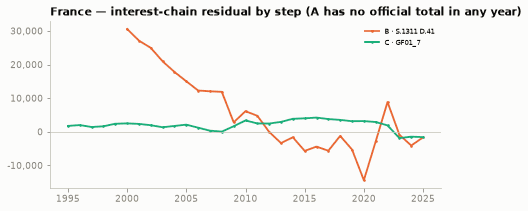

In [20]:
residual_over_time(INTEREST, "FRA", ["B_s1311_d41", "C_s13_gf01_7"],
                    "France — interest-chain residual by step (A has no official total in any year)")


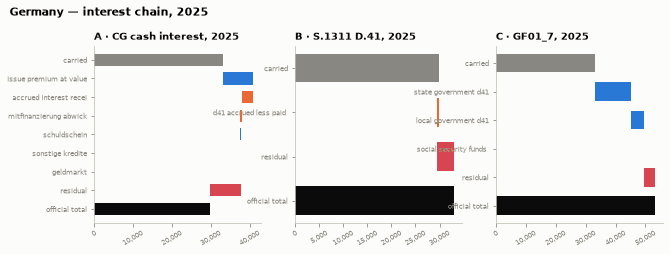

In [21]:
deu_year = waterfall_page(INTEREST, "DEU", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"], "interest")


**Reading the Germany panels.** Step A is the fullest of the three: the
Kreditaufnahmebericht's Verzinsung annex gives central-government cash
interest directly, with `Geldmarkt`, `Schuldschein`, other-credit and
Abwicklungsanstalten/KfW co-financing interest as declared bridge items
against the register sum — the step-A residual is essentially zero (leaves
vs ministry total agree to within rounding). Step B's residual (+€3.2bn) is
**cash-to-accrual timing and premium/discount amortisation**: cash interest
paid in the year versus D.41 interest accrued to it. Step C's residual
(+€3.7bn) is **subsector consolidation and the COFOG-vs-D.41 wedge**, after
adding state, local and social-security D.41 interest as bridge items.


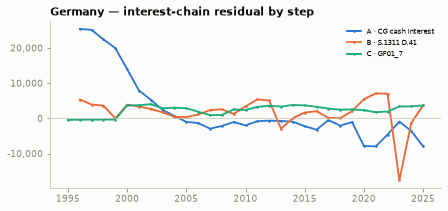

In [22]:
residual_over_time(INTEREST, "DEU", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"],
                    "Germany — interest-chain residual by step")


## 5. The financing chain

`debt_financing_reconciliation.csv` mirrors §4's shape for financing:
register net issuance → step A (central-government net cash requirement /
besoin de financement / Nettokreditaufnahme) → step B (S.1311 net borrowing)
→ step C (the package's `NLB`, as net borrowing). The waterfalls read the same
way as the interest chain.

**Sign convention.** The whole chain runs in **net-borrowing sign**: positive
when the government borrows more. The register sum and step A's official
total are published that way; the ESA quantities at steps B and C are net
lending(+)/borrowing(−), so the chain carries them as `−B.9` and `−NLB` and
says so in the `basis` column (`net borrowing = -B.9`). A residual at step B
is therefore a genuine reconciliation gap — the cash-to-accrual and
financial-transaction wedge (the stock-flow adjustment) — not a sign
artefact; where an official breakdown of that wedge exists (ONS REC2 for the
UK, Eurostat's EDP stock-flow items for France and Germany) it appears as
bridge items and the residual shrinks accordingly.


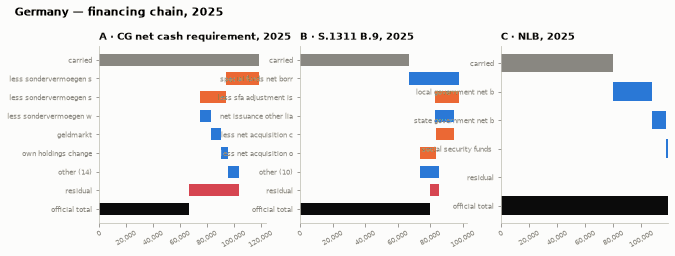

In [23]:
deu_fyear = waterfall_page(FINANCING, "DEU", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"], "financing")


**Reading the Germany panels.** Step A takes the register (the BMF instrument
tree, Bund-wide) to the core budget's Nettokreditaufnahme: money-market and
Schuldschein credits are added, the special funds' own borrowing (Sondervermögen
rows of the Datenportal) is subtracted, and the Kreditaufnahmebericht's own
derivation items (sonstige Einnahmen zur Schuldentilgung, Eigenbestand change,
the non-cash Selbstbewirtschaftung and special-fund lines, Rücklage) close the
step to zero for every edition whose annex parses. Step B's residual is the
stock-flow adjustment between the cash NKA and S.1311 net borrowing (accrual
timing, financial transactions such as loans and equity, the special funds
that are inside S.1311 but outside the NKA). Step C closes exactly once
state, local and social-security net borrowing are added: Eurostat's S.13
`B.9` is the sum of its four subsectors.


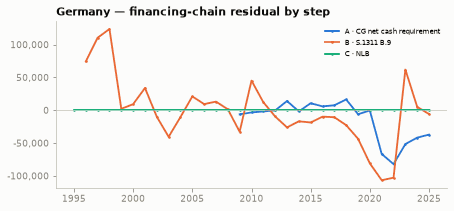

In [24]:
residual_over_time(FINANCING, "DEU", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"],
                    "Germany — financing-chain residual by step")


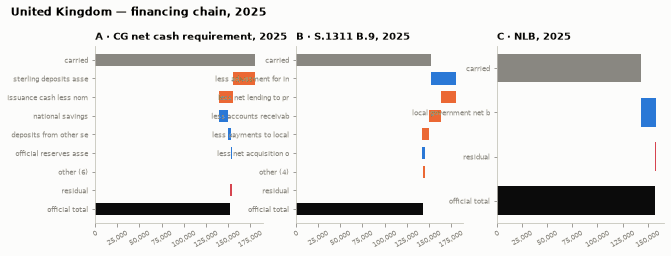

In [25]:
gbr_fyear = waterfall_page(FINANCING, "GBR", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"], "financing")


**Reading the UK panels.** Step A bridges the register (Σ net issuance of
gilts and Treasury bills at nominal, from §7) to the CGNCR with one computed
item — `issuance_cash_less_nominal`, the cash each operation raised less the
nominal it created (negative in the discount years 2022–2025, +£34.5bn in
2020) — and the remaining ONS Appendix S lines (National Savings, tax
instruments, deposits, loans, reserves, sterling deposits). The residual is
within ±£13bn 2010–2025 except 2022 (−£61bn) and 2008–2009: the ONS gilt row
(F.332) is consolidated within central government — net of gilts acquired by
the DMA and other CG bodies — while the register is the DMO's gross creation
(OQ-9). Step B's residual is the CGNCR-to-CG-net-borrowing reconciliation
(ONS REC2), step C's is local government's net borrowing plus consolidation.


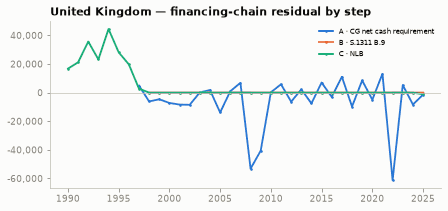

In [26]:
residual_over_time(FINANCING, "GBR", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"],
                    "United Kingdom — financing-chain residual by step")


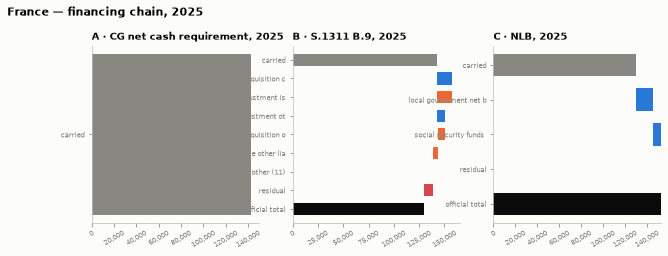

In [27]:
fra_fyear = waterfall_page(FINANCING, "FRA", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"], "financing")


**Reading the France panels.** Unlike the interest chain, the financing
register itself is *not* blocked here — the INSEE-redistributed AFT aggregates
(BTF and OAT/BTAN, from 2010) and Eurostat's S.1311 short- and long-term
securities (from 2001) carry net issuance as the year-on-year change in the
stock — so panel A shows a "carried" bar. What is blocked is the **official
total it should reconcile to**: `FRA_AFT_FINANCEMENT`, the AFT's own tableau
de financement, has no data in this run (OQ-8), so panel A has no closing bar
and no residual. Step B therefore reconciles the register directly against
S.1311 net borrowing; its residual is the stock-flow adjustment (buy-backs and
indexation are inside the Δstock, financial transactions and accruals are
not) plus the ODAC perimeter (CADES and the other central bodies are S.1311
but not the État). Step C closes exactly once local-government and
social-security net borrowing are added.

*Update (D-S10-007).* From 2000 the register step is Σ net issuance at
nominal from the AFT's auction histories, redemptions at maturity and the
published buybacks. With step A (the État's besoin de financement) blocked
the chain meets `S.1311 B.9` at step B, where the residual is the whole
cash-to-accrual and financial-transaction wedge plus the AFT's aggregate-only
buybacks and premia — published, not allocated.


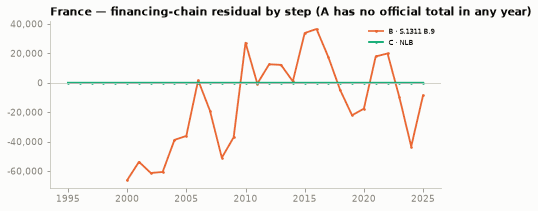

In [28]:
residual_over_time(FINANCING, "FRA", ["B_s1311_b9", "C_s13_nlb"],
                    "France — financing-chain residual by step (A has no official total in any year)")


## 6. Coverage

Two summaries of how much of each chain is actually populated, rather than
reading it off the charts above one country at a time.

**First and last year with a value**, per (country, chain, step) — for the
official total the chain reconciles to, and separately for the residual that
step actually published (a step can carry an official total for a year but
no residual, when the previous step's carried value is itself unknown — see
France's step B above).


In [29]:
def coverage(df, chain):
    d = df.copy()
    d["chain"] = chain
    off = d[d.item == "official_total"].dropna(subset=["value_lcu_mn"])
    res = d[d.item == "residual"].dropna(subset=["value_lcu_mn"])
    g_off = off.groupby(["iso3", "chain", "step"]).year.agg(official_total_first="min", official_total_last="max")
    g_res = res.groupby(["iso3", "chain", "step"]).year.agg(residual_first="min", residual_last="max")
    return g_off.join(g_res, how="outer")


cov = pd.concat([coverage(INTEREST, "interest"), coverage(FINANCING, "financing")]).sort_index()
cov


official_total_first  \
iso3 chain     step                                          
DEU  financing A_cg_cash_requirement                  2009   
               B_s1311_b9                             1995   
               C_s13_nlb                              1995   
               register                               1996   
     interest  A_cg_cash                              1996   
               B_s1311_d41                            1995   
               C_s13_gf01_7                           1991   
               register                               1996   
FRA  financing B_s1311_b9                             1995   
               C_s13_nlb                              1995   
               register                               2000   
     interest  B_s1311_d41                            1995   
               C_s13_gf01_7                           1978   
               register                               2000   
GBR  financing A_cg_cash_requirement                  1997   
               B_s1311_b9                             1998   
               C_s13_nlb                              1990   
               register                               1982   
     interest  A_cg_cash                              2009   
               B_s1311_d41                            1987   
               C_s13_gf01_7                           1987   
               register                               1982   

                                      official_total_last  residual_first  \
iso3 chain     step                                                         
DEU  financing A_cg_cash_requirement                 2025          2009.0   
               B_s1311_b9                            2025          1996.0   
               C_s13_nlb                             2025          1995.0   
               register                              2026             NaN   
     interest  A_cg_cash                             2025          1996.0   
               B_s1311_d41                           2025          1996.0   
               C_s13_gf01_7                          2025          1995.0   
               register                              2026             NaN   
FRA  financing B_s1311_b9                            2025          2000.0   
               C_s13_nlb                             2025          1995.0   
               register                              2026             NaN   
     interest  B_s1311_d41                           2025          2000.0   
               C_s13_gf01_7                          2025          1995.0   
               register                              2026             NaN   
GBR  financing A_cg_cash_requirement                 2025          1997.0   
               B_s1311_b9                            2025          1998.0   
               C_s13_nlb                             2025          1990.0   
               register                              2027             NaN   
     interest  A_cg_cash                             2024          2009.0   
               B_s1311_d41                           2025          1987.0   
               C_s13_gf01_7                          2025          1987.0   
               register                              2027             NaN   

                                      residual_last  
iso3 chain     step                                  
DEU  financing A_cg_cash_requirement         2025.0  
               B_s1311_b9                    2025.0  
               C_s13_nlb                     2025.0  
               register                         NaN  
     interest  A_cg_cash                     2025.0  
               B_s1311_d41                   2025.0  
               C_s13_gf01_7                  2025.0  
               register                         NaN  
FRA  financing B_s1311_b9                    2025.0  
               C_s13_nlb                     2025.0  
               register                         NaN 

**Which sources are blocked** — an `item_source_id` that appears only ever
paired with a null value, across all three chain/total files, is a source
this run could not reach at all (as opposed to one that is simply outside a
year's coverage).


In [30]:
def all_null_sources(df):
    g = df.groupby(["iso3", "item_source_id"]).value_lcu_mn.apply(lambda s: s.isna().all())
    return g[g].reset_index()[["iso3", "item_source_id"]]


blocked = pd.concat([
    all_null_sources(INTEREST).assign(chain="interest"),
    all_null_sources(FINANCING).assign(chain="financing"),
    all_null_sources(OFFICIAL).assign(chain="official_totals"),
]).drop_duplicates(subset=["iso3", "item_source_id"]).sort_values(["iso3", "item_source_id"])
blocked.reset_index(drop=True)


,iso3,item_source_id,chain
0,FRA,FRA_AFT_FINANCEMENT,financing
1,FRA,FRA_PLF_P117,interest


## 7. The per-security registers: Germany, the United Kingdom and France

For Germany and the UK the register step of §4 and §5 is no longer a
published aggregate but the sum over securities: `debt_securities` (terms),
`debt_positions` (31 December nominal per security, plus the office's latest
close of business), `debt_flows` (every auction, syndication, tender,
conversion, switch, buyback and redemption), `debt_index_ratios`, and the
engine's outputs `debt_interest_by_security`, `debt_maturity_profile` and
`debt_issuance_by_bucket`. The aggregate rows of §3 remain as the **V31 /
V39 cross-checks** — reported, never enforced.

**How the UK positions were obtained.** The DMO publishes no historical
positions table by date, but it publishes the complete operations record
since 1981 (D2.1E, signed nominals) and two anchors — the nominal in issue
today (D1A) and the nominal outstanding at redemption for every gilt redeemed
since 1981 (D1C). Each gilt's history is its anchor walked back through its
operations; where the record falls short of the anchor (pre-1981 issues, a
few omitted early tenders, the older stocks with no operation at all) the
difference is one `implied` flow at 1981-01-01, published and never spread.
Index ratios are recomputed from the ONS RPI with the DMO's 3-month-lag
formula, which reproduces the office's own table to 5 decimals.

**France.** The AFT publishes its register as HTML tables and Excel files
behind a challenge that only a person's browser passes; the committee saved
them. The encours pages give every OAT, OATi, OAT€i and BTF line with its
outstanding nominal at the retrieval date; the auction histories (OAT/BTAN
and BTF since January 1999, syndications) are the operations; the coefficient
files give the AFT's own daily indexation coefficients. As for the UK, each
line's history is the encours walked back through its operations, with the
shortfall — issuance before 1999, or buybacks the AFT publishes only in
aggregate — as one `implied` flow, dated at 1999-01-01 or at the snapshot and
never spread. Σ BTF at 31 December reproduces the AFT's own total to the euro
2009–2020; the uplifted linkers are within 3% of the AFT's total; fixed-rate
lines run 1–4% above it in recent years, the buybacks of lines near maturity
that no per-line file carries.


In [31]:
SECS = load("debt_securities")
POS = load("debt_positions"); POS["as_of"] = pd.to_datetime(POS["as_of"])
FLOWS = load("debt_flows"); FLOWS["settlement_date"] = pd.to_datetime(FLOWS["settlement_date"])
IBS = load("debt_interest_by_security")
PROFILE = load("debt_maturity_profile")
BUCKETS = load("debt_issuance_by_bucket")

summary = (SECS.groupby(["iso3", "instrument_class"]).size().unstack(fill_value=0))
summary["total"] = summary.sum(axis=1)
ye = POS[POS.position_type == "rolled_from_flows"] if "rolled_from_flows" in set(POS.position_type) else POS
span = POS[POS.as_of.dt.month == 12].groupby("iso3").as_of.agg(["min", "max"]).map(lambda d: d.year)
summary = summary.join(span.rename(columns={"min": "first year-end", "max": "last year-end"}))
summary


/tmp/ipykernel_807/1278449642.py:12: DtypeWarning: Columns (0: reference_values_used) have mixed types. Specify dtype option on import or set low_memory=False.
  load = lambda n: pd.read_csv(DELIV / f"{n}.csv", float_precision="round_trip")


,bill,fixed_bullet,floating,inflation_linked,other,total,first year-end,last year-end
iso3,,,,,,,,
DEU,384,400,2,9,859,1654,1995,2025
FRA,1402,166,0,35,0,1603,1999,2025
GBR,1406,283,2,56,0,1747,1981,2025


**Σ register positions against the official stock (V31).** For each country the
31 December nominal summed over the register, by instrument class, next to the
in-register aggregate rows of §3. Germany reproduces the office's
Umlaufvolumen; the UK's index-linked nominal matches HMT's DMR to the million
(2023–2025) while conventional gilts sit above the ONS/DMR figure, which is
consolidated within central government (OQ-9). The UK chart shows the
register's uplifted total as well: the ONS series is at uplifted nominal.


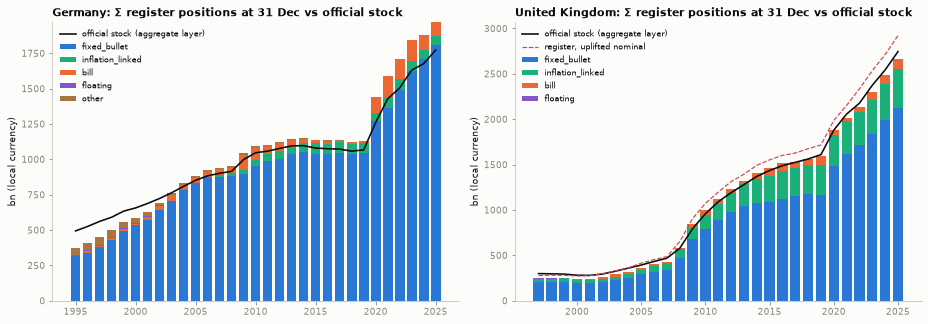

In [32]:
def register_stock(iso3):
    p = POS[(POS.iso3 == iso3) & (POS.as_of.dt.month == 12) & (POS.as_of.dt.day == 31)]
    p = p.merge(SECS[SECS.iso3 == iso3][["security_id", "instrument_class"]], on="security_id")
    by = p.pivot_table(index=p.as_of.dt.year, columns="instrument_class", values="nominal_lcu_mn", aggfunc="sum").fillna(0)
    upl = p.groupby(p.as_of.dt.year).nominal_uplifted_lcu_mn.sum(min_count=1)
    unind = p[p.nominal_uplifted_lcu_mn.notna()].groupby(p[p.nominal_uplifted_lcu_mn.notna()].as_of.dt.year).nominal_lcu_mn.sum()
    return by, (by.sum(axis=1) + (upl - unind).reindex(by.index).fillna(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, iso3 in zip(axes, ["DEU", "GBR"]):
    by, uplifted = register_stock(iso3)
    by = by.loc[1995:] if iso3 == "DEU" else by.loc[1997:]
    bottom = 0
    for klass in [c for c in ["fixed_bullet", "inflation_linked", "bill", "floating", "other"] if c in by.columns]:
        ax.bar(by.index, by[klass] / 1000, bottom=bottom, color=CLASS_COLOR[klass], label=klass, width=0.8)
        bottom = bottom + by[klass] / 1000
    off = CLASS_AGG[(CLASS_AGG.iso3 == iso3) & (CLASS_AGG.measure == "stock_year_end") & CLASS_AGG.in_register]
    if iso3 == "GBR":   # the DMR class split rows are alternatives to gilts_all, not additions
        off = off[off.sub_type.isin(["gilts_all", "treasury_bills"])]
    off = off.groupby("year").value_lcu_mn.sum()
    off = off[off.index >= by.index.min()]
    ax.plot(off.index, off / 1000, color=INK, linewidth=1.6, label="official stock (aggregate layer)")
    if iso3 == "GBR":
        u = uplifted.loc[by.index]
        ax.plot(u.index, u / 1000, color=RED, linewidth=1.2, linestyle="--", label="register, uplifted nominal")
    ax.set_title(f"{COUNTRY[iso3]}: Σ register positions at 31 Dec vs official stock", loc="left", fontsize=11)
    ax.set_ylabel("bn (local currency)")
    ax.legend(frameon=False, fontsize=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()


**Interest by security against the official step-A total (V39).** Σ
`debt_interest_by_security` by class, on the basis each country's chain uses
(cash for Germany, accrued for the UK), against the finance ministry's own
total. The UK accrued series includes the RPI uplift accrual (the large
inflation-linked bars of 2022–2023) and the amortisation of issue discounts.


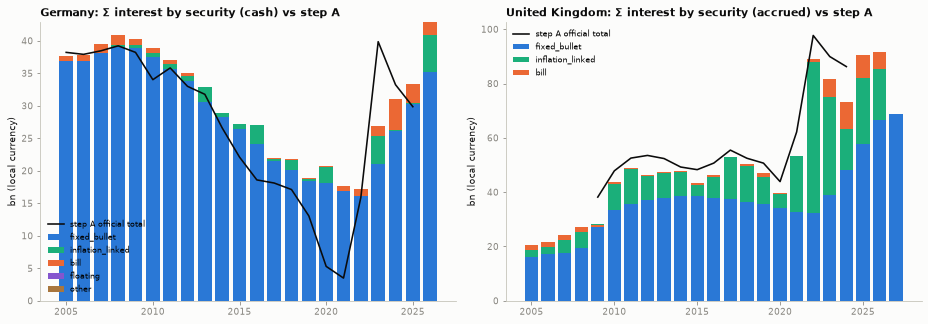

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (iso3, basis, y0) in zip(axes, [("DEU", "cash", 2005), ("GBR", "accrued", 2005)]):
    it = IBS[(IBS.iso3 == iso3) & (IBS.basis == basis) & (IBS.computability == "computed")]
    it = it.merge(SECS[SECS.iso3 == iso3][["security_id", "instrument_class"]], on="security_id")
    by = it.pivot_table(index="year", columns="instrument_class", values="total_lcu_mn", aggfunc="sum").fillna(0).loc[y0:]
    bottom = 0
    for klass in [c for c in ["fixed_bullet", "inflation_linked", "bill", "floating", "other"] if c in by.columns]:
        ax.bar(by.index, by[klass] / 1000, bottom=bottom, color=CLASS_COLOR[klass], label=klass, width=0.8)
        bottom = bottom + by[klass] / 1000
    off = INTEREST[(INTEREST.iso3 == iso3) & (INTEREST.step == "A_cg_cash") & (INTEREST.item == "official_total")]
    off = off.dropna(subset=["value_lcu_mn"]).set_index("year").value_lcu_mn
    off = off[off.index >= y0]
    ax.plot(off.index, off / 1000, color=INK, linewidth=1.6, label="step A official total")
    ax.set_title(f"{COUNTRY[iso3]}: Σ interest by security ({basis}) vs step A", loc="left", fontsize=11)
    ax.set_ylabel("bn (local currency)")
    ax.legend(frameon=False, fontsize=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()


**The maturity profile (DD7).** Nominal outstanding at each office's latest
snapshot by residual-maturity bucket and instrument class — the table the yield-curve
simulation will run on. Buckets are right-closed years to maturity
(0–1, 1–2, 2–3, 3–5, 5–7, 7–10, 10–15, 15–20, 20–30, 30+; undated stock in 30+).


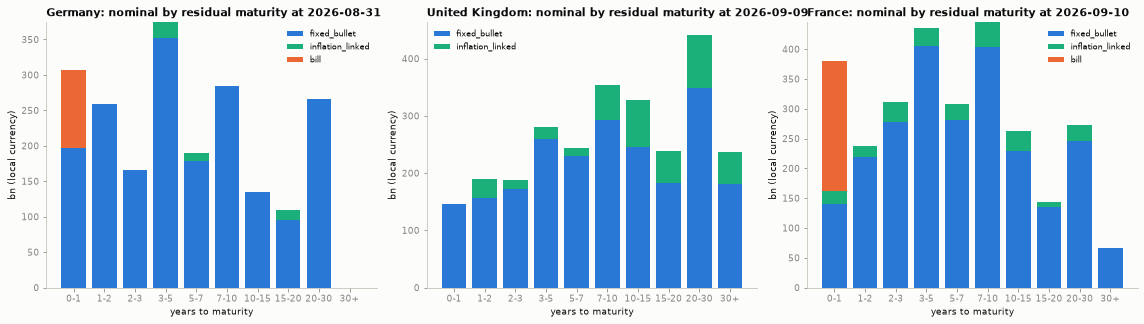

In [34]:
BUCKET_ORDER = ["0-1", "1-2", "2-3", "3-5", "5-7", "7-10", "10-15", "15-20", "20-30", "30+"]
# one hue, light (shortest) to dark (longest): the buckets are ordinal, not categorical
BUCKET_COLOR = dict(zip(BUCKET_ORDER, plt.cm.Blues([0.18 + 0.082 * i for i in range(10)])))
CLASS_ORDER = ["fixed_bullet", "inflation_linked", "floating", "bill", "other"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, iso3 in zip(axes, ["DEU", "GBR", "FRA"]):
    p = PROFILE[PROFILE.iso3 == iso3]
    latest = p.as_of.max()
    p = p[p.as_of == latest]
    by = p.pivot_table(index="bucket", columns="instrument_class", values="nominal_lcu_mn", aggfunc="sum").reindex(BUCKET_ORDER).fillna(0)
    bottom = 0
    for klass in [c for c in ["fixed_bullet", "inflation_linked", "bill", "floating", "other"] if c in by.columns]:
        ax.bar(by.index, by[klass] / 1000, bottom=bottom, color=CLASS_COLOR[klass], label=klass)
        bottom = bottom + by[klass] / 1000
    ax.set_title(f"{COUNTRY[iso3]}: nominal by residual maturity at {str(latest)[:10]}", loc="left", fontsize=11)
    ax.set_ylabel("bn (local currency)"); ax.set_xlabel("years to maturity")
    ax.legend(frameon=False, fontsize=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()


**Issuance by residual maturity at settlement.** Gross issuance per year in
the same buckets: the maturity the debt office chose, year by year.


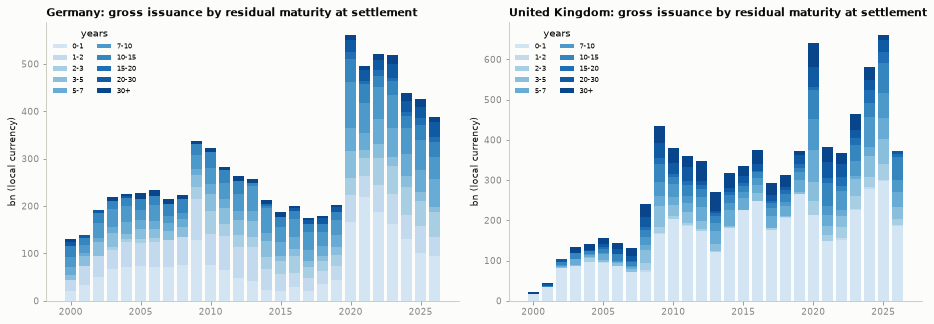

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (iso3, y0) in zip(axes, [("DEU", 2000), ("GBR", 2000)]):
    b = BUCKETS[(BUCKETS.iso3 == iso3) & (BUCKETS.year >= y0)]
    by = b.pivot_table(index="year", columns="bucket", values="gross_nominal_lcu_mn", aggfunc="sum").reindex(columns=BUCKET_ORDER).fillna(0)
    bottom = 0
    for col in BUCKET_ORDER:
        colour = BUCKET_COLOR[col]
        ax.bar(by.index, by[col] / 1000, bottom=bottom, color=colour, label=col, width=0.8)
        bottom = bottom + by[col] / 1000
    ax.set_title(f"{COUNTRY[iso3]}: gross issuance by residual maturity at settlement", loc="left", fontsize=11)
    ax.set_ylabel("bn (local currency)")
    ax.legend(frameon=False, fontsize=7, ncol=2, title="years")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()


**Notional outstanding by maturity bucket through time.** Σ nominal at each 31
December over every security in the register, by residual-maturity bucket
(all instrument classes together; bills are always in 0–1). Read it as the
office's term structure of the debt: how much rolls off within a year, how
much sits beyond thirty. Each country's series starts where its register does
(UK 1981, France and Germany 1999 — Germany's year-ends before 1999 are the
office's own lists but its flows start in 1999).


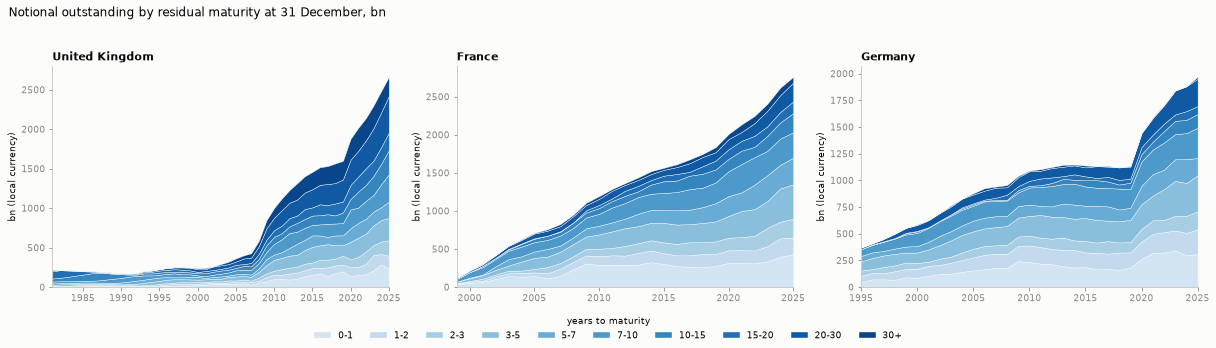

In [36]:
def bucket_stock(iso3):
    p = PROFILE[(PROFILE.iso3 == iso3)]
    p = p[pd.to_datetime(p.as_of).dt.month.eq(12) & pd.to_datetime(p.as_of).dt.day.eq(31)]
    by = p.pivot_table(index=pd.to_datetime(p.as_of).dt.year, columns="bucket", values="nominal_lcu_mn", aggfunc="sum")
    return by.reindex(columns=BUCKET_ORDER).fillna(0) / 1000

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, iso3 in zip(axes, ["GBR", "FRA", "DEU"]):
    by = bucket_stock(iso3)
    ax.stackplot(by.index, [by[b] for b in BUCKET_ORDER], labels=BUCKET_ORDER,
                 colors=[BUCKET_COLOR[b] for b in BUCKET_ORDER], linewidth=0.4, edgecolor=SURFACE)
    ax.set_title(COUNTRY[iso3], loc="left", fontsize=11)
    ax.set_ylabel("bn (local currency)")
    ax.set_xlim(by.index.min(), by.index.max())
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("Notional outstanding by residual maturity at 31 December, bn", x=0.01, ha="left", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, ncol=10, loc="lower center", title="years to maturity", title_fontsize=9)
plt.tight_layout(rect=(0, 0.09, 1, 0.95))


**Interest paid by maturity bucket through time.** The cash interest of every
security in `debt_interest_by_security` (coupons, the uplift paid at
redemption, bill discounts), attributed to the bucket of the security's
residual maturity at the start of the year — 31 December of the previous year,
or the first issue date for a security born during the year — with the same
right-closed edges. So a ten-year bond pays in the 7–10 bucket in its first
years and moves left as it ages: the chart shows where in the curve the
interest bill sits, and how a curve shift would reach it. Securities whose
interest is not computable (the floating-rate gilts and the German FRN, DD10)
are not in it.
The UK spikes are the cash uplift paid when an index-linked gilt redeems
(2013, 2016, 2020, 2024); on the accrued basis, also in the table, the series
is smooth.


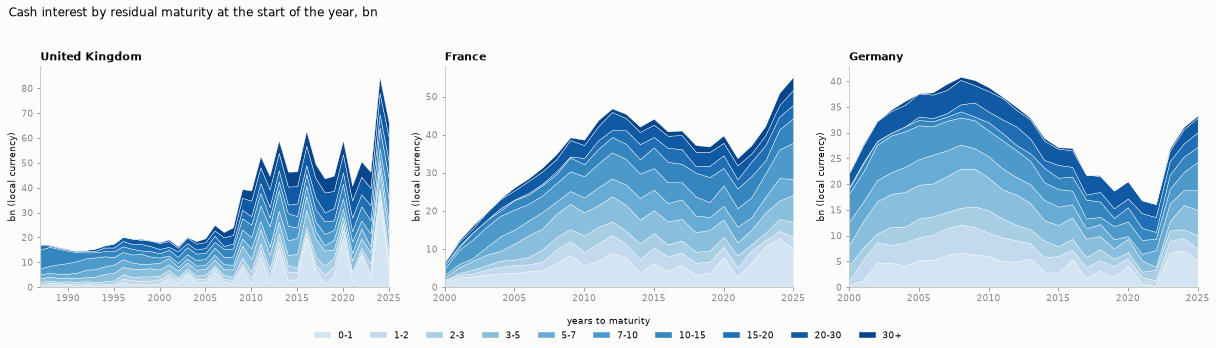

In [37]:
EDGES = [0, 1, 2, 3, 5, 7, 10, 15, 20, 30]

def bucket_of_years(y):
    if pd.isna(y):
        return "30+"                                          # undated stock
    if y <= 0:
        return "0-1"                                          # matures inside the year
    for lo, hi, lab in zip(EDGES[:-1], EDGES[1:], BUCKET_ORDER[:-1]):
        if lo < y <= hi:
            return lab
    return "30+"

def interest_by_bucket(iso3):
    it = IBS[(IBS.iso3 == iso3) & (IBS.basis == "cash") & (IBS.computability == "computed")]
    it = it.merge(SECS[SECS.iso3 == iso3][["security_id", "maturity_date", "first_issue_date"]], on="security_id")
    start = pd.to_datetime((it.year - 1).astype(str) + "-12-31")
    first = pd.to_datetime(it.first_issue_date)
    ref = start.where(first.isna() | (first <= start), first)
    residual = (pd.to_datetime(it.maturity_date) - ref).dt.days / 365.25
    it = it.assign(bucket=[bucket_of_years(v) for v in residual])
    by = it.pivot_table(index="year", columns="bucket", values="total_lcu_mn", aggfunc="sum")
    return by.reindex(columns=BUCKET_ORDER).fillna(0) / 1000

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (iso3, y0) in zip(axes, [("GBR", 1987), ("FRA", 2000), ("DEU", 2000)]):
    by = interest_by_bucket(iso3)
    by = by.loc[y0:2025]
    ax.stackplot(by.index, [by[b] for b in BUCKET_ORDER], labels=BUCKET_ORDER,
                 colors=[BUCKET_COLOR[b] for b in BUCKET_ORDER], linewidth=0.4, edgecolor=SURFACE)
    ax.set_title(COUNTRY[iso3], loc="left", fontsize=11)
    ax.set_ylabel("bn (local currency)")
    ax.set_xlim(by.index.min(), by.index.max())
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("Cash interest by residual maturity at the start of the year, bn", x=0.01, ha="left", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, ncol=10, loc="lower center", title="years to maturity", title_fontsize=9)
plt.tight_layout(rect=(0, 0.09, 1, 0.95))


The same two tables, as numbers: the latest five year-ends of the notional
split, and the latest five years of the interest split, per country.


In [38]:
frames = []
for iso3 in ["GBR", "FRA", "DEU"]:
    st = bucket_stock(iso3).tail(5).round(1); st.insert(0, "measure", "notional 31 Dec, bn"); st.insert(0, "country", iso3)
    it = interest_by_bucket(iso3).loc[:2025].tail(5).round(2); it.insert(0, "measure", "cash interest, bn"); it.insert(0, "country", iso3)
    frames += [st, it]
pd.concat(frames)


bucket,country,measure,0-1,1-2,2-3,3-5,5-7,7-10,10-15,15-20,20-30,30+
2021,GBR,"notional 31 Dec, bn",154.00,102.80,124.80,243.60,188.10,194.20,201.80,191.10,325.00,291.60
2022,GBR,"notional 31 Dec, bn",163.60,129.10,158.40,225.70,187.20,228.50,200.80,209.60,353.40,283.80
2023,GBR,"notional 31 Dec, bn",212.60,194.10,125.30,249.30,174.60,210.60,243.00,193.70,409.60,286.70
2024,GBR,"notional 31 Dec, bn",287.90,130.50,157.80,273.10,163.70,291.10,258.80,210.20,440.50,269.30
2025,GBR,"notional 31 Dec, bn",237.50,159.70,196.30,281.70,204.80,348.50,303.60,222.50,465.60,242.60
2021,GBR,"cash interest, bn",2.32,2.65,1.09,4.68,2.86,4.73,4.13,5.52,6.93,5.89
2022,GBR,"cash interest, bn",12.89,1.10,1.91,3.69,4.05,3.18,5.75,4.85,6.99,6.22
2023,GBR,"cash interest, bn",3.80,2.02,3.73,4.48,2.44,5.20,5.25,6.07,6.98,6.43
2024,GBR,"cash interest, bn",34.79,4.29,0.85,7.91,3.67,4.54,8.17,5.47,8.40,6.54
2025,GBR,"cash interest, bn",7.65,0.87,5.04,7.20,5.44,8.98,8.56,6.82,9.68,5.94


**What the UK register does not yet carry.** The office's own year-end
positions (the page's export link with a date is not reproducible by URL —
OQ-8), per-ISIN Bank of England APF holdings (DD11; the BOE_APF snapshots are
in the store), the LIBID fixings of the two floating-rate gilts (DD10), and
bills issued bilaterally outside the tender history (the register's bill stock
equals the ONS figure 2001–2006 and runs below it afterwards). For France: per-line buybacks (the AFT publishes rachats only in aggregate), the
lines issued before 1999, and the État's own cash totals (step A, blocked).
